# **19 · 데이터 품질 게이트 종합 — 흩어진 자기검증을 하나의 판정표로 닫는다**

### **"src 모듈 3종의 self_validation(시뮬레이션 회복 검정) + 패널 무결성 6종 + parquet 라운드트립 + 지수 범위 게이트를 한 자리에서 일괄 실행 — P3(전처리) 트랙의 출구 검문소, 전 게이트 PASS"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 파이프라인 전 구간의 품질 게이트 · 방법 = **self_validation 일괄 실행 + 무결성 assert 판정표**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리(마감 게이트)** · CRISP-DM **P3 출구** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 추정기 3종(MGCFA·정렬법·MK/APC)은 **정답을 아는 시뮬레이션 데이터**에서 그 정답을 회복하는가 — 구현 자체의 자기검증?
> **Q2.** 결합 패널의 무결성(행수·범위·가중·라운드트립)은 전 항목에서 성립하는가?
> **Q3.** 게이트가 하나라도 깨지면 어디를 봐야 하는가 — 게이트 ↔ 담당 노트북의 지도?

## **이 노트북의 위상 — 1x 데이터 트랙의 출구 검문소**

`12`~`18`이 각자 하나의 주제(재검증·가중·특수코드·crosswalk·2022·단일문항·신뢰도)를 깊게 팠다면, 19는 **넓게 한 번에** 닫는다: src 모듈에 흩어져 있던 `self_validation()`(각 노트북이 개별 인용)을 일괄 실행하고, 패널 무결성을 전 항목 assert로 고정한 판정표를 남긴다. 이 노트북이 초록색이면 P4(2x 모델링 트랙)는 데이터 걱정 없이 시작한다.

- **로직 SSOT(thin import)**: `alignment.self_validation` · `mgcfa_invariance.self_validation` · `trend_apc.self_validation` · `health_index_panel._check_range`·`_validate_2025_direction`.
- ⚠️ 실행 비용: 자기검증 3종은 시뮬레이션 적합을 포함해 **수 분** 걸릴 수 있다 — 이 비용이 곧 "캐시된 판정의 재탕이 아니라 방금 재검증한 결과"라는 입증이다.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 게이트의 설계 — **Decision Box ①** | 게이트 지도 |
| 2 | [실행] 추정기 자기검증 3종(시뮬레이션 회복) | PASS 3종 |
| 3 | [실행] 패널 무결성 6종 + 라운드트립 | assert |
| 4 | [실행] 지수 범위·방향 게이트(A트랙 연결) | PASS |
| 5 | [입증] 종합 판정표 + [시각화] | 판정표 |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import io
from contextlib import redirect_stdout

import harmonize as hz
import alignment as al
import mgcfa_invariance as mi
import trend_apc as T
import health_index_panel as hp

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
GATES = []   # (게이트, 담당 노트북, 판정 bool) 누적
print(f"패널 {len(panel):,}행 · 게이트 판정표 초기화")

패널 90,996행 · 게이트 판정표 초기화


## **1. [전제] 게이트의 설계 — 무엇을 어디서 지키는가**

### **Decision Box ① — 품질 게이트: 분산 유지 vs 종합 검문소**

**기준: 파이프라인 개정 시 "무엇이 깨졌는지"를 얼마나 빨리 알 수 있는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 각 노트북의 검증 셀로 충분 | 12~18이 각자 assert | ❌ 개정 후 전체 상태를 알려면 노트북 7권을 재실행·열람해야 함 — 회귀 확인 비용이 큼 |
| (b) CI식 테스트 스위트 신설 | pytest 등 별도 테스트 코드 | ❌ 검증 로직을 **다시 구현**하게 됨(재구현 금지 원칙과 충돌) + 제출물(노트북) 밖의 인프라 |
| (c) **self_validation 일괄 + 판정표 노트북** | src에 이미 있는 자기검증을 한 노트북이 일괄 호출 | ✅ **채택** — 로직 추가 0, 재실행 1회로 전 게이트 상태 파악. 각 게이트에 담당 노트북을 매핑해 실패 시 진입점 제공 |

**게이트 ↔ 담당 지도**: 추정기 회복(§2) → `21`·`23`·`24` / 무결성(§3) → `11`·`13`·`14` / crosswalk는 `15`가 자체 게이트 / 지수 범위(§4) → `03`·`05`.

## **2. [실행] 추정기 자기검증 3종 — 정답을 아는 데이터에서 정답을 회복하는가**

각 src 모듈의 `self_validation()`은 알려진 모수로 데이터를 시뮬레이션해 추정기가 그 모수를 회복하는지 검사한다: **MGCFA**(불변→scalar 성립 / 절편 비동등→scalar 실패의 양방향), **정렬법**(완전불변·부분비동등 회복 + 과다비동등에서 성능 저하 = 게이트 실질성), **MK/APC**(단조·평탄·감소 패턴 판별 + IE 기간효과 형상 회복).

In [2]:
for name, fn, nb_ref in [("MGCFA 판정 양방향", mi.self_validation, "21"),
                          ("정렬법 잠재평균 회복", al.self_validation, "23"),
                          ("MK 패턴 판별 + IE 회복", T.self_validation, "24")]:
    print(f"── {name} (담당 노트북 {nb_ref}) " + "─" * 30)
    ok = bool(fn())
    GATES.append((f"추정기: {name}", nb_ref, ok))
    print(f"   → 게이트 {'PASS' if ok else 'FAIL'}\n")

── MGCFA 판정 양방향 (담당 노트북 21) ──────────────────────────────



===== MGCFA 순차검정 — 자기검증A: 완전불변(평균만 상이) (G=5, N=15,000) =====
     level    chi2  df    CFI  RMSEA    dCFI  dRMSEA verdict
configural 13.6335  10 0.9999 0.0110     NaN     NaN     NaN
    metric 27.4400  22 0.9998 0.0091 -0.0001 -0.0019   동등 성립
    scalar 37.8863  34 0.9999 0.0062  0.0001 -0.0029   동등 성립



===== MGCFA 순차검정 — 자기검증B: 절편 비동등 (G=5, N=15,000) =====
     level      chi2  df    CFI  RMSEA    dCFI  dRMSEA verdict
configural    4.2619  10 1.0000 0.0000     NaN     NaN     NaN
    metric   17.7145  22 1.0000 0.0000  0.0000  0.0000   동등 성립
    scalar 3048.3493  34 0.8910 0.1719 -0.1090  0.1719     비동등

자기검증 판정 → A(불변→scalar적합 CFI>.95): True | B(절편비동등→scalar ΔCFI<−.01): True
   → 게이트 PASS

── 정렬법 잠재평균 회복 (담당 노트북 23) ──────────────────────────────
◆ 자기검증 — 정렬법 잠재평균 회복


  [A 완전불변] corr(α̂,α)=0.9983 maxbias=0.0289 α̂=[0.0, 0.108, 0.184, 0.306, 0.429, 0.498, 0.609]


  [B 부분비동등(≤20%)] corr(α̂,α)=0.9982 maxbias=0.0291 α̂=[0.0, 0.079, 0.191, 0.288, 0.406, 0.471, 0.604]


  [C 과다비동등(>20%)] corr(α̂,α)=0.9986 maxbias=0.0303 α̂=[0.0, 0.094, 0.185, 0.309, 0.37, 0.485, 0.581]
자기검증 판정 → A(불변 회복 corr>.99·bias<.10): True | B(부분비동등 회복 corr>.97·bias<.15): True | C(과다비동등 회복 저하 확인: bias_C>bias_B=True)
   → 게이트 PASS

── MK 패턴 판별 + IE 회복 (담당 노트북 24) ──────────────────────────────
◆ 자기검증


  [MK] 증가 S=21 p=0.0004 | 감소 S=-21 p=0.0004 | 평탄 p=0.7726 → OK
  [APC] IE 기간효과 회복 corr=0.9963 (rank_ok=True) → OK
   → 게이트 PASS



## **3. [실행] 패널 무결성 — 결합 산출물의 계약 조건**

`11`이 만든 parquet이 지켜야 하는 계약을 전 항목 검사한다: 행수·연도 구성·값 범위·가중 성질·중복 없음·라운드트립(저장→재로드 후 동일).

In [3]:
import tempfile

def gate(name, cond, nb_ref):
    GATES.append((name, nb_ref, bool(cond)))
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")

EXPECT_N = {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}
n_by = panel.groupby("year").size().to_dict()
gate("행수: 총 90,996 · 연도별 기대 일치", len(panel) == 90996 and n_by == EXPECT_N, "11")
gate("resp_id 중복 없음", panel["resp_id"].is_unique, "11")

num_ok = True
for col, lo, hi in [("trust_news_overall", 1, 5), ("cred_fair", 1, 5), ("cred_professional", 1, 5),
                    ("cred_accurate", 1, 5), ("richness_fixed8", 0, 8), ("richness_incl", 0, 11),
                    ("edu", 1, 4), ("income_band7", 1, 7), ("job", 1, 13), ("region", 1, 17)]:
    s = pd.to_numeric(panel[col], errors="coerce").dropna()
    num_ok &= bool(s.between(lo, hi).all())
gate("값 범위 10종(신뢰·richness·인구)", num_ok, "14")

gate("가중 성질: wt_year_eq 연도합 = N/T · wt_within 평균 = 1",
     np.allclose(panel.groupby("year")["wt_year_eq"].sum(), len(panel) / hz.T)
     and np.allclose(panel.groupby("year")["wt_within"].mean(), 1.0), "13")

na_all = panel[["cred_fair", "cred_professional", "cred_accurate"]].isna().all(axis=1)
gate("cred 핵심3 전체결측 행 없음(7개년 존재)", not bool(na_all.groupby(panel["year"]).all().any()), "15")

with tempfile.TemporaryDirectory() as td:
    tmp = Path(td) / "rt.parquet"
    panel.to_parquet(tmp)
    rt = pd.read_parquet(tmp)
    gate("parquet 라운드트립(저장→재로드 동일)", rt.equals(panel), "11")

  [PASS] 행수: 총 90,996 · 연도별 기대 일치
  [PASS] resp_id 중복 없음
  [PASS] 값 범위 10종(신뢰·richness·인구)
  [PASS] 가중 성질: wt_year_eq 연도합 = N/T · wt_within 평균 = 1
  [PASS] cred 핵심3 전체결측 행 없음(7개년 존재)


  [PASS] parquet 라운드트립(저장→재로드 동일)


## **4. [실행] 지수 범위·방향 게이트 — A트랙 연결부**

`health_index_panel`의 범위 게이트(전 지수 [1,100]·NA 없음)와 2025 방향 정합(패널 산출 ↔ 2025 단년 모듈의 응답자 단위 양의 상관)을 실행한다. 출력에 FAIL이 없어야 통과.

In [4]:
buf = io.StringIO()
with redirect_stdout(buf):
    t_ok = hp._check_range("신뢰", hp.trust_index_panel(panel), ["trust_index"])
    d_ok = hp._check_range("다양성", hp.diversity_index_panel(panel),
                           ["diversity_index_fixed8", "diversity_index_incl"])
    n_ok = hp._check_range("NCHI", hp.nchi_by_year(panel), ["trust_index", "diversity_index", "nchi"])
    hp._validate_2025_direction(panel)
log = buf.getvalue()
print(log, end="")
dir_ok = ("FAIL" not in log)
gate("지수 범위 게이트(신뢰·다양성·NCHI 전부 [1,100]·NA 0)", t_ok and d_ok and n_ok, "03")
gate("2025 방향 정합(패널 ↔ 단년 모듈, corr>0)", dir_ok, "03")

  [OK] 신뢰.trust_index: 범위[51.3, 60.1] NA=0
  [OK] 다양성.diversity_index_fixed8: 범위[26.8, 30.3] NA=0
  [OK] 다양성.diversity_index_incl: 범위[19.8, 23.7] NA=0
  [OK] NCHI.trust_index: 범위[51.3, 60.1] NA=0
  [OK] NCHI.diversity_index: 범위[26.8, 30.3] NA=0
  [OK] NCHI.nchi: 범위[38.2, 41.9] NA=0
  [OK] 2025 신뢰 방향 정합: corr(패널 cred3, 단년 22문항)=+0.806 (>0 기대)
  [OK] 2025 다양성 방향 정합: corr(패널 richness8, 단년 richness)=+0.943 (>0 기대)
  [PASS] 지수 범위 게이트(신뢰·다양성·NCHI 전부 [1,100]·NA 0)
  [PASS] 2025 방향 정합(패널 ↔ 단년 모듈, corr>0)


## **5. [입증] 종합 판정표**

**[시각화] 게이트 보드** — 전 게이트의 PASS/FAIL을 한 장으로. 이 보드가 전부 초록일 때만 P4 트랙의 전제가 성립한다.

C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


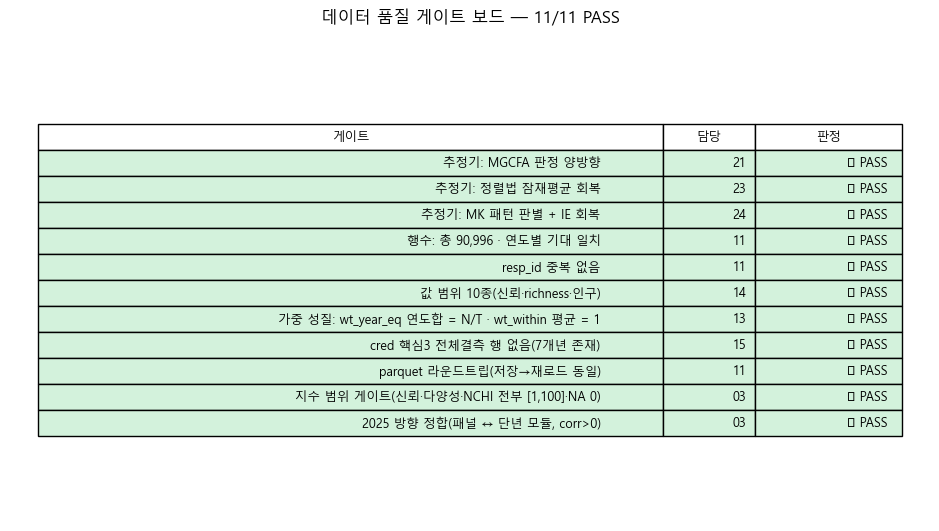

종합 판정: 전 게이트 11종 PASS — P3 출구 게이트 폐쇄


In [5]:
board = pd.DataFrame(GATES, columns=["게이트", "담당 노트북", "판정"])
board["판정표시"] = board["판정"].map({True: "✅ PASS", False: "❌ FAIL"})

fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(board) + 0.8))
ax.axis("off")
colors = ["#d3f2dc" if ok else "#ffd6d6" for ok in board["판정"]]
tb = ax.table(cellText=board[["게이트", "담당 노트북", "판정표시"]].values,
              colLabels=["게이트", "담당", "판정"], loc="center",
              cellColours=[[c, c, c] for c in colors],
              colWidths=[0.68, 0.10, 0.16])
tb.auto_set_font_size(False); tb.set_fontsize(9); tb.scale(1, 1.35)
ax.set_title(f"데이터 품질 게이트 보드 — {int(board['판정'].sum())}/{len(board)} PASS", pad=12)
fig.tight_layout(); plt.show()

assert board["판정"].all(), f"FAIL 게이트: {board.loc[~board['판정'], '게이트'].tolist()}"
print(f"종합 판정: 전 게이트 {len(board)}종 PASS — P3 출구 게이트 폐쇄")

## **6. 종합**

### **연구질문 답**

- **Q1** — 그렇다. MGCFA(불변↔비동등 양방향 판별)·정렬법(불변·부분비동등 회복 + 과다비동등 저하 확인)·MK/APC(패턴 판별·IE 형상 회복) 전부 시뮬레이션 정답을 회복했다(§2) — 구현 오류 가설이 추정기 수준에서 배제된다.
- **Q2** — 그렇다. 행수·중복·값 범위·가중 성질·핵심3 존재·라운드트립 전부 PASS(§3), 지수 범위·2025 방향 정합 PASS(§4).
- **Q3** — 판정표의 '담당 노트북' 열이 지도다(§5): 게이트가 깨지면 그 노트북부터 연다. 파이프라인 개정 시 **이 노트북 1회 재실행 = 전 구간 회귀 확인**.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 추정기 자기검증 3종 일괄 | 3/3 PASS |
| 3 | 패널 무결성 6종 + 라운드트립 | PASS |
| 4 | 지수 범위·방향 게이트 | PASS |
| 5 | 종합 판정표 [시각화] | **전 게이트 PASS** |

**다음**: 1x 데이터 트랙(10~19) 완결 — 2x 모델링 트랙(20~29)의 심층 노트북(`25`~`29`)으로.